## Assignment 1: Markowitz Portfolio Optimization

Aim - To constructs a **10-stock portfolio across 3 sectors**, evaluates **three annual risk budgets** (`20%`, `28%`, `40%`), and compares **convex optimization** 
with **Monte Carlo simulation**.

Also refer to [README](README.md).

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import yfinance as yf
import cvxpy as cp

np.random.seed(42)

### Portfolio Universe, Data Source, and Assumptions


#### Portfolio Universe
The portfolio uses **10 U.S. large-cap stocks** across **three sectors**.

- **Technology:** AAPL, MSFT, NVDA, ORCL
- **Finance:** JPM, V, BAC
- **Health Care:** JNJ, PFE, UNH

#### Data Source and Date Range
- **Source:** Yahoo Finance via `yfinance`
- **Price field:** `close` column obtained with `auto_adjust=True`
- **Download window requested:** `2020-01-01` to `2025-12-03`
- **Saved output window:** `2020-01-02` to `2025-12-02`

#### Model
- Markwotiz Mean Variance Optimisation
- **Long-only:** `w >= 0`
- **Fully invested:** `sum(w) = 1`
- **No transaction costs or shorting**
- **Annualization:** 252 trading days for both expected return and covariance


In [2]:
tickers = [
    'AAPL', 'MSFT', 'NVDA', 'ORCL',
    'JPM', 'V', 'BAC',
    'JNJ', 'PFE', 'UNH'
]

df = yf.download(tickers, start='2020-01-01', end='2025-12-03', group_by='ticker', auto_adjust=True, threads=True)

df.head()

[                       0%                       ]

[**********            20%                       ]  2 of 10 completed

[**************        30%                       ]  3 of 10 completed

[*******************   40%                       ]  4 of 10 completed

[**********************50%                       ]  5 of 10 completed

...

[**********************70%*********              ]  7 of 10 completed

[**********************80%*************          ]  8 of 10 completed

[**********************90%******************     ]  9 of 10 completed

[*********************100%***********************]  10 of 10 completed

Ticker           AAPL                                                   ORCL  \
Price            Open       High        Low      Close     Volume       Open   
Date                                                                           
2020-01-02  71.344054  72.394086  71.091184  72.333878  135480400  48.530080   
2020-01-03  71.563213  72.389265  71.406674  71.630646  146322800  48.275014   
2020-01-06  70.753999  72.239927  70.503531  72.201393  118387200  48.612084   
2020-01-07  72.211041  72.466322  71.642681  71.861839  108872000  49.094917   
2020-01-08  71.565614  73.318870  71.565614  73.017830  132079200  49.359188   

Ticker                                                 ...        PFE  \
Price            High        Low      Close    Volume  ...       Open   
Date                                                   ...              
2020-01-02  49.158683  48.493638  49.149574  13899600  ...  27.158936   
2020-01-03  49.240695  48.238573  48.976498  11026700  ...  26.758119   
2020-01-06  49.377342  48.602972  49.231579  10982400  ...  26.827222   
2020-01-07  49.495768  48.839832  49.340893  12015400  ...  27.034544   
2020-01-08  49.963138  49.139571  49.533054  11856700  ...  26.785762   

Ticker                                                        JNJ              \
Price            High        Low      Close    Volume        Open        High   
Date                                                                            
2020-01-02  27.193487  26.868687  27.048363  16514072  122.554185  122.680217   
2020-01-03  27.117474  26.723565  26.903244  14922848  120.563044  122.134140   
2020-01-06  26.951616  26.744296  26.868687  15771951  120.983110  121.151139   
2020-01-07  27.041454  26.730474  26.778849  20108107  120.991508  122.201342   
2020-01-08  27.103652  26.778852  26.993082  16403507  121.714064  122.646643   

Ticker                                       
Price              Low       Close   Volume  
Date                                         
2020-01-02  121.890464  122.638206  5777000  
2020-01-03  120.142964  121.218369  5752400  
2020-01-06  120.016930  121.067131  7731300  
2020-01-07  118.781895  121.806465  7382900  
2020-01-08  120.731078  121.789688  6605800  

[5 rows x 50 columns]

In [3]:
adj_close = df.xs('Close', level=1, axis=1)
print(adj_close.head(),"\n\n")
print(adj_close.info())

Ticker           AAPL       ORCL         JPM           V         UNH  \
Date                                                                   
2020-01-02  72.333878  49.149574  118.430328  182.431076  263.196869   
2020-01-03  71.630646  48.976498  116.867500  180.980148  260.533417   
2020-01-06  72.201393  49.231579  116.774544  180.588806  262.342010   
2020-01-07  71.861839  49.340893  114.789322  180.111588  260.758392   
2020-01-08  73.017830  49.533054  115.684784  183.194687  266.256195   

Ticker            BAC      NVDA        MSFT        PFE         JNJ  
Date                                                                
2020-01-02  30.587564  5.970754  151.829544  27.048363  122.638206  
2020-01-03  29.952459  5.875186  149.938980  26.903244  121.218369  
2020-01-06  29.909550  5.899825  150.326584  26.868687  121.067131  
2020-01-07  29.712152  5.971253  148.955917  26.778849  121.806465  
2020-01-08  30.012541  5.982452  151.328537  26.993082  121.789688   


<class 'p

### Data Preparation and Return/Risk Definitions


#### 1. Simple Returns

This notebook uses **simple daily returns** computed from adjusted close prices with `pct_change()`:

$$r_t = \frac{P_t}{P_{t-1}} - 1$$

In [4]:
returns = adj_close.pct_change()
returns.head()

Ticker,AAPL,ORCL,JPM,V,UNH,BAC,NVDA,MSFT,PFE,JNJ
Date,,,,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.009722,-0.003521,-0.013196,-0.007953,-0.010120,-0.020764,-0.016006,-0.012452,-0.005365,-0.011577
2020-01-06,0.007968,0.005208,-0.000795,-0.002162,0.006942,-0.001433,0.004194,0.002585,-0.001285,-0.001248
2020-01-07,-0.004703,0.002220,-0.017000,-0.002643,-0.006036,-0.006600,0.012107,-0.009118,-0.003344,0.006107
2020-01-08,0.016086,0.003895,0.007801,0.017118,0.021084,0.010110,0.001875,0.015928,0.008000,-0.000138


In [5]:
returns = returns.dropna()
returns.describe()

Ticker,AAPL,ORCL,JPM,V,UNH,BAC,NVDA,MSFT,PFE,JNJ
count,1487.000000,1487.000000,1487.000000,1487.000000,1487.000000,1487.000000,1487.000000,1487.000000,1487.000000,1487.000000
mean,0.001126,0.001232,0.000832,0.000541,0.000359,0.000602,0.002861,0.000960,0.000076,0.000420
std,0.020156,0.024418,0.019811,0.017076,0.021129,0.021794,0.033657,0.018695,0.017205,0.012389
min,-0.128647,-0.137908,-0.149649,-0.135472,-0.223797,-0.153974,-0.184521,-0.147390,-0.077347,-0.075916
25%,-0.008237,-0.008728,-0.008009,-0.007338,-0.008054,-0.009766,-0.015791,-0.007931,-0.009351,-0.005479
50%,0.001172,0.001287,0.000977,0.001255,0.000748,0.000451,0.003210,0.001109,-0.000731,0.000406
75%,0.011590,0.010663,0.009977,0.008622,0.009359,0.010811,0.021989,0.010485,0.008597,0.006178
max,0.153289,0.359488,0.180125,0.138426,0.127989,0.177962,0.243696,0.142169,0.108552,0.079977


#### 2. Expected Returns
Expected annual returns are taken to be the sample mean of the daily returns and then annuliazed by multiplying by 252(no .of trading days in a year):

$$\mu = 252 \times \mathbb{E}[r_t]$$


In [6]:
mu = returns.mean() * 252
mu

Ticker
AAPL    0.283875
ORCL    0.310383
JPM     0.209614
V       0.136246
UNH     0.090562
BAC     0.151630
NVDA    0.720888
MSFT    0.241864
PFE     0.019225
JNJ     0.105823
dtype: float64

#### 3. Covariance Matrix
Annualized portfolio risk is calculated using the sample covariance matrix $(= \frac{1}{N-1}\sum_{i=1}^N (r_i - \mu)(r_i - \mu)^\top)$ where N is the number of observations i.e. the number of trading days. 

So annualized risk is:

$$\hat{\Sigma}_{\text{ann}} = 252 \times \hat{\Sigma}_{\text{daily}}$$


In [7]:
Sigma = returns.cov() * 252
print(f"Annualized covariance matrix: shape={Sigma.shape}, diag range=[{np.diag(Sigma).min():.3f}, {np.diag(Sigma).max():.3f}]")

returns

Annualized covariance matrix: shape=(10, 10), diag range=[0.039, 0.285]


Ticker,AAPL,ORCL,JPM,V,UNH,BAC,NVDA,MSFT,PFE,JNJ
Date,,,,,,,,,,
2020-01-03,-0.009722,-0.003521,-0.013196,-0.007953,-0.010120,-0.020764,-0.016006,-0.012452,-0.005365,-0.011577
2020-01-06,0.007968,0.005208,-0.000795,-0.002162,0.006942,-0.001433,0.004194,0.002585,-0.001285,-0.001248
2020-01-07,-0.004703,0.002220,-0.017000,-0.002643,-0.006036,-0.006600,0.012107,-0.009118,-0.003344,0.006107
2020-01-08,0.016086,0.003895,0.007801,0.017118,0.021084,0.010110,0.001875,0.015928,0.008000,-0.000138
2020-01-09,0.021241,0.004619,0.003651,0.006930,-0.005677,0.001716,0.010983,0.012493,-0.004353,0.002966
...,...,...,...,...,...,...,...,...,...,...
2025-11-25,0.003805,-0.016227,0.016778,0.015882,0.022661,0.010591,-0.025911,0.006308,0.019826,0.009377
2025-11-26,0.002094,0.040248,0.015314,-0.002212,0.010513,0.009718,0.013722,0.017841,-0.000389,0.004306
2025-11-28,0.004684,-0.014686,0.017683,0.001947,0.000182,0.012455,-0.018085,0.013409,0.001167,-0.003083


### Exploratory Data Analysis (EDA)

#### 1. Cumulative Growth View
You can see the how the 1$ would have grown. Bassicall given wot 

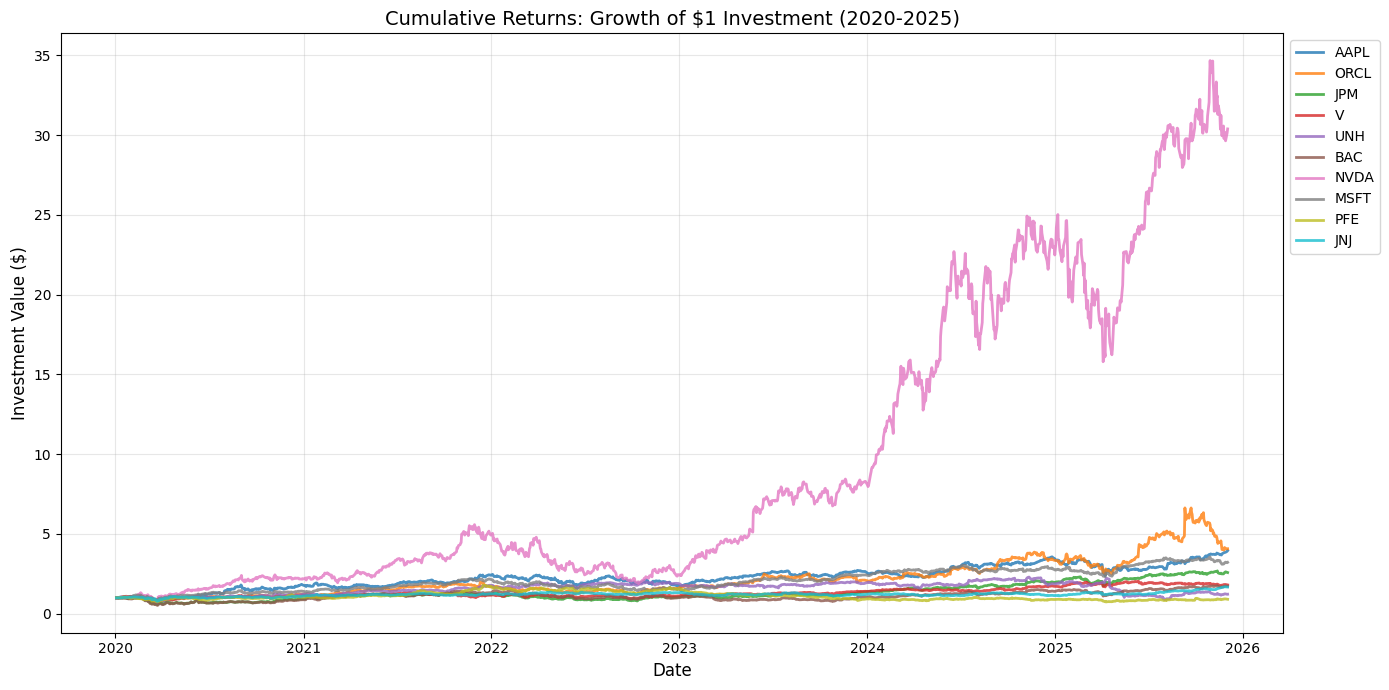

In [8]:
cumulative_returns = (1 + returns).cumprod()

plt.figure(figsize=(14, 7))

colors = plt.get_cmap('tab10', len(cumulative_returns.columns))

for i, c in enumerate(cumulative_returns.columns):
    plt.plot(cumulative_returns.index, cumulative_returns[c], 
             label=c, linewidth=2, alpha=0.8, color=colors(i))

plt.title('Cumulative Returns: Growth of $1 Investment (2020-2025)', fontsize=14)
plt.ylabel('Investment Value ($)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Cross-Asset Correlations
Correlation matrix of the stocks to understand the relationships between them and diversification prospects.

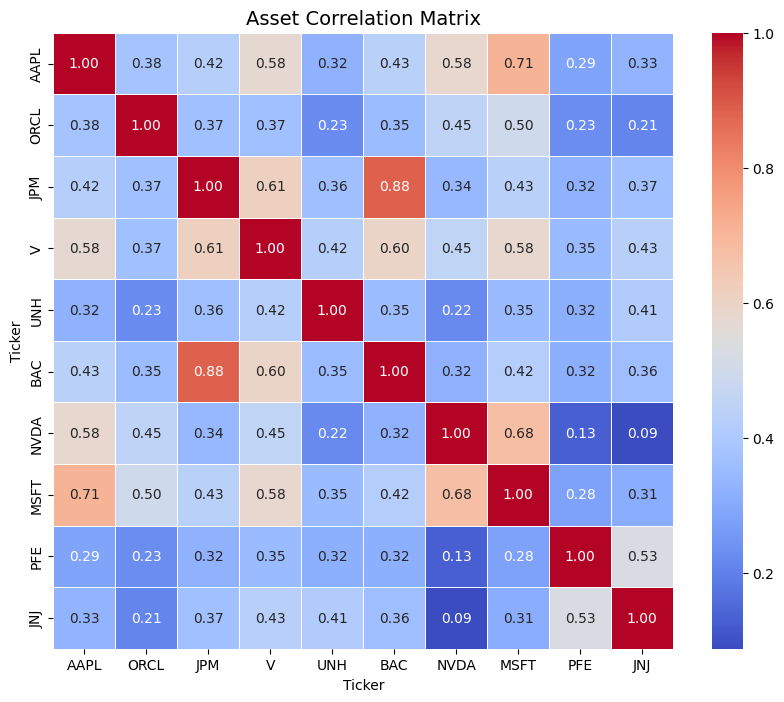

In [9]:
plt.figure(figsize=(10, 8))

corr_matrix = returns.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Asset Correlation Matrix', fontsize=14)
plt.show()

### Markowitz Formulation

For a target annual volatility budget $\sigma_{\text{target}}$, the Markowitz problem is:

$$
\begin{aligned}
& \text{maximize} && \mu^T w \\
& \text{subject to} && w^T \Sigma w \le \sigma_{\text{target}}^2 \\
& && \mathbf{1}^T w = 1 \\
& && w \ge 0
\end{aligned}
$$

Intuitively it solves the problem that what is the best return(the objective function) give a risk bound(1st constraint) and there is no shorting(last constraint) and that i am fully vested(2nd last constraint).

### Risk-Level Definition

- **Low Risk:** `20%`
- **Medium Risk:** `28%`
- **High Risk:** `40%`

These budgets span conservative, balanced, and aggressive positions within the feasible set, while remaining fixed across both optimization methods.


### Method 1: Convex Optimization (ECOS)

The primary convex benchmark solves the target-volatility Markowitz problem directly with `cvxpy` and the `ECOS` solver. Additional solver experiments are retained in the appendix so that the principal comparison remains aligned with the assignment requirements.


#### What ECOS Solves

ECOS is a primal-dual interior-point solver for second-order cone programs (SOCPs). Its objective must be linear, so the quadratic risk constraint $w^\top \Sigma w \le \sigma_{\text{target}}^2$ has to be lifted into a cone.

#### Casting the Markowitz Target-Risk Problem as an SOCP

The target-risk problem is

$$
\max_w \; \mu^\top w
\quad \text{s.t.} \quad
w^\top \Sigma w \le \sigma_{\text{target}}^2, \;
\mathbf{1}^\top w = 1, \;
w \ge 0.
$$

Cholesky-factor $\Sigma = L L^\top$, then

$$
w^\top \Sigma w \le \sigma_{\text{target}}^2
\;\Longleftrightarrow\;
\|L^\top w\|_2 \le \sigma_{\text{target}}
\;\Longleftrightarrow\;
(\sigma_{\text{target}},\, L^\top w) \in \mathcal{Q}^{n+1}.
$$

Negating the objective (ECOS minimizes), the SOCP ECOS actually solves is

$$
\min_w \; -\mu^\top w
\quad \text{s.t.} \quad
\mathbf{1}^\top w = 1, \; w \ge 0, \;
(\sigma_{\text{target}},\, L^\top w) \in \mathcal{Q}^{n+1}.
$$

Cones: one zero cone (budget equality), $n$ nonneg rows (long-only), one second-order cone of dimension $n+1$ (risk cap).

#### Equivalence with the Lagrangian / Penalty Form

Section 5 shows the target-risk form and the penalty form $\max_w \mu^\top w - \gamma w^\top \Sigma w$ trace the same efficient frontier, with the risk-constraint multiplier $\lambda$ playing the role of $\gamma$. At the optimum, the KKT stationarity condition gives

$$
\mu = 2\lambda \Sigma w + \eta \mathbf{1} - \nu, \qquad \nu \ge 0,
$$

which matches the gradient of $\mu^\top w - \gamma w^\top \Sigma w$ when $\gamma = \lambda$. Under standard regularity (Slater's condition, an active risk constraint at the boundary, $\Sigma \succ 0$), the same $w$ is recovered on the smooth segments of the long-only frontier up to solver tolerance, regardless of which form is solved; only the parametrization differs.

In [10]:
def maximize_return(target_risk, mu, Sigma):
    n = len(mu)
    w_init = cp.Variable(n)

    objective = cp.Maximize(mu.T @ w_init)

    risk_variance = cp.quad_form(w_init, Sigma)
    target_variance = target_risk ** 2

    # long-only, fully invested, with a hard volatility cap
    constraints = [
        cp.sum(w_init) == 1,
        w_init >= 0,
        risk_variance <= target_variance
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.ECOS)

    return w_init.value, prob.value

In [11]:
n = len(mu)
mu_np = mu.values
Sigma_np = Sigma.values
actual_tickers = mu.index

risk_targets = [0.20, 0.28, 0.40]

ecos_results = {}
ecos_weight_series = {}
opt_risks = []
opt_returns = []

print(f"{'Risk':<12} | {'Exp. Return':<12} | {'Weights (Top 3)'}")

for target_risk in risk_targets:
    w_opt, ret_opt = maximize_return(target_risk, mu_np, Sigma_np)

    risk_opt = np.sqrt(np.dot(w_opt.T, np.dot(Sigma_np, w_opt)))
    ecos_results[target_risk] = w_opt
    ecos_weight_series[target_risk] = pd.Series(w_opt, index=actual_tickers)
    opt_risks.append(risk_opt)
    opt_returns.append(ret_opt)

    w_series = pd.Series(w_opt, index=actual_tickers).sort_values(ascending=False)
    w_top = w_series[w_series > 0.01]

    top_3_str = ", ".join([f"{t}: {w:.1%}" for t, w in w_top.head(3).items()])
    print(f"{risk_opt:.2%}        | {ret_opt:.2%}        | {top_3_str}")

print()
print("Full ECOS weight table (all tickers):")
ticker_order = ['AAPL', 'MSFT', 'NVDA', 'ORCL', 'JPM', 'V', 'BAC', 'JNJ', 'PFE', 'UNH']
header = f"{'Ticker':<8}" + "".join([f"{'Low':>10}", f"{'Medium':>10}", f"{'High':>10}"])
print(header)
for t in ticker_order:
    row = f"{t:<8}"
    for target_risk in risk_targets:
        w = ecos_weight_series[target_risk].get(t, 0.0)
        row += f"{w:>10.1%}"
    print(row)

Risk         | Exp. Return  | Weights (Top 3)
20.00%        | 25.05%        | JNJ: 62.1%, NVDA: 18.4%, ORCL: 8.1%
28.00%        | 39.74%        | NVDA: 44.1%, JNJ: 44.0%, ORCL: 8.0%
40.00%        | 55.82%        | NVDA: 71.0%, JNJ: 21.3%, ORCL: 7.7%

Full ECOS weight table (all tickers):
Ticker         Low    Medium      High
AAPL          4.6%      0.0%      0.0%
MSFT          0.0%      0.0%      0.0%
NVDA         18.4%     44.1%     71.0%
ORCL          8.1%      8.0%      7.7%
JPM           6.9%      3.9%      0.0%
V             0.0%      0.0%      0.0%
BAC           0.0%      0.0%      0.0%
JNJ          62.1%     44.0%     21.3%
PFE           0.0%      0.0%      0.0%
UNH           0.0%      0.0%      0.0%


### Convex Optimization Results

The ECOS solution matches the risk budgets closely and produces sparse long-only allocations concentrated in the most efficient names within the selected universe.


### Method 2: Monte Carlo Simulation

Random portfolio generation is used as a sampling-based benchmark. The principal submitted comparison uses the **Dirichlet-based sampler** below; alternative sampling designs are retained in the appendix.


#### Dirichlet-Based Sampler

The submitted Monte Carlo benchmark samples long-only portfolios on the simplex with Dirichlet draws and adds a small concentrated tail near the boundary of the feasible set. For each risk budget, the reported Monte Carlo portfolio is the highest-return sampled portfolio that satisfies the volatility limit.


In [12]:
def generate_dirichlet_portfolios(mu_vec, Sigma_mat, n_simulations=100000, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    n_assets = len(mu_vec)
    results = np.zeros((3, n_simulations))
    all_weights = np.zeros((n_simulations, n_assets))

    for i in range(n_simulations):
        if i < 80000:
            weights = rng.dirichlet(np.ones(n_assets)) # these ones mostly form the central cloud.
        else:
            # concentrated 2-asset boundary portfolios, these one usually lie on the efficient frontier.
            weights = np.zeros(n_assets)
            indices = rng.choice(n_assets, 2, replace=False)
            w_split = rng.random()
            weights[indices[0]] = w_split
            weights[indices[1]] = 1 - w_split

        all_weights[i] = weights
        port_return = np.dot(weights, mu_vec)
        port_risk = np.sqrt(np.dot(weights.T, np.dot(Sigma_mat, weights)))
        sharpe_ratio = port_return / port_risk

        results[0, i] = port_return
        results[1, i] = port_risk
        results[2, i] = sharpe_ratio

        if (i + 1) % 10000 == 0:
            print(f"  [{i+1:>6d}] ret={port_return:.4f}  risk={port_risk:.4f}  sharpe={sharpe_ratio:.4f}")

    df = pd.DataFrame(results.T, columns=['Return', 'Risk', 'Sharpe'])
    return df, all_weights

In [13]:
df_mc, mc_weights = generate_dirichlet_portfolios(mu_np, Sigma_np)

  [ 10000] ret=0.1788  risk=0.2160  sharpe=0.8279


  [ 20000] ret=0.1944  risk=0.2205  sharpe=0.8819


  [ 30000] ret=0.3133  risk=0.2563  sharpe=1.2226


  [ 40000] ret=0.2256  risk=0.2399  sharpe=0.9404


  [ 50000] ret=0.3423  risk=0.2809  sharpe=1.2187


  [ 60000] ret=0.3478  risk=0.2817  sharpe=1.2347


  [ 70000] ret=0.2849  risk=0.2549  sharpe=1.1177


  [ 80000] ret=0.1744  risk=0.2209  sharpe=0.7896


  [ 90000] ret=0.2740  risk=0.3096  sharpe=0.8851


  [100000] ret=0.1748  risk=0.2411  sharpe=0.7250


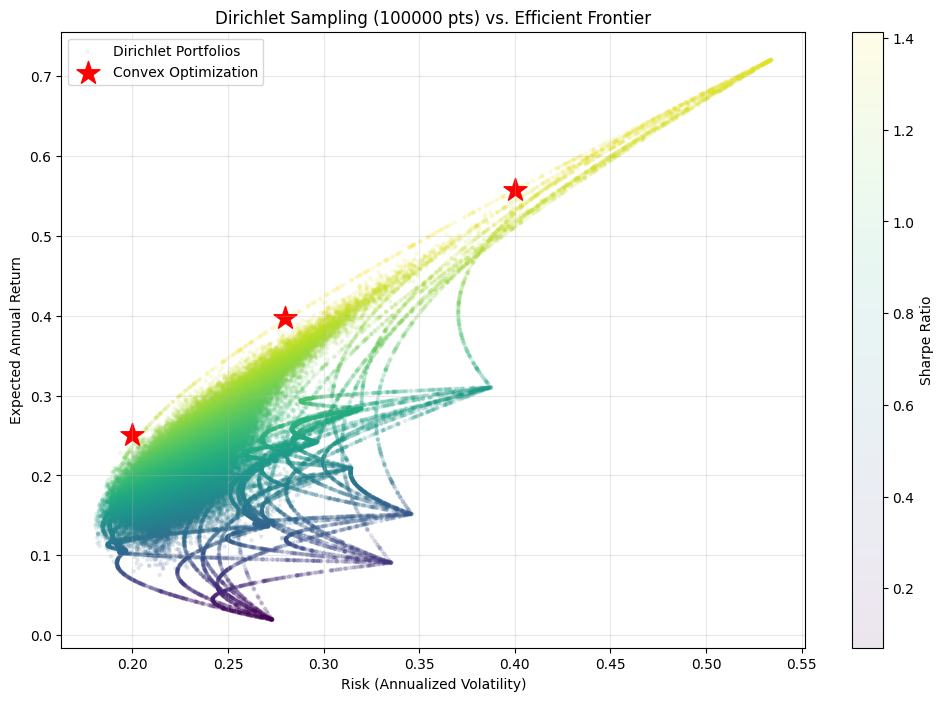

In [14]:
plt.figure(figsize=(12, 8))

plt.scatter(df_mc['Risk'], df_mc['Return'], c=df_mc['Sharpe'], cmap='viridis', alpha=0.1, s=5, label='Dirichlet Portfolios')
plt.colorbar(label='Sharpe Ratio')

plt.scatter(opt_risks, opt_returns, color='red', marker='*', s=300, label='Convex Optimization')

plt.title(f'Dirichlet Sampling (100000 pts) vs. Efficient Frontier')
plt.xlabel('Risk (Annualized Volatility)')
plt.ylabel('Expected Annual Return')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
risk_targets = [0.20, 0.28, 0.40]

mc_opt_risks = []
mc_opt_returns = []
mc_best_weights = {}

print(f"{'Risk':<12} | {'Exp. Return':<12} | {'Weights (Top 3)'}")

for target in risk_targets:
    subset = df_mc[df_mc['Risk'] <= target]

    if not subset.empty:
        best_idx = subset['Return'].idxmax()
        best_port = subset.loc[best_idx]
        best_weights = mc_weights[best_idx]

        mc_opt_risks.append(best_port['Risk'])
        mc_opt_returns.append(best_port['Return'])
        mc_best_weights[target] = pd.Series(best_weights, index=actual_tickers)

        w_series = pd.Series(best_weights, index=actual_tickers).sort_values(ascending=False)
        w_top = w_series[w_series > 0.01]

        top_str = ", ".join([f"{t}: {w:.1%}" for t, w in w_top.head(3).items()])
        print(f"{best_port['Risk']:.2%}        | {best_port['Return']:.2%}        | {top_str}")

print()
print("Full MC weight table:")
ticker_order = ['AAPL', 'MSFT', 'NVDA', 'ORCL', 'JPM', 'V', 'BAC', 'JNJ', 'PFE', 'UNH']
header = f"{'Ticker':<8}" + "".join([f"{'Low':>10}", f"{'Medium':>10}", f"{'High':>10}"])
print(header)
for t in ticker_order:
    row = f"{t:<8}"
    for tgt in risk_targets:
        w = mc_best_weights[tgt].get(t, 0.0)
        row += f"{w:>10.1%}"
    print(row)

Risk         | Exp. Return  | Weights (Top 3)
19.78%        | 23.52%        | JNJ: 59.8%, NVDA: 15.7%, MSFT: 10.0%
27.78%        | 39.14%        | JNJ: 53.6%, NVDA: 46.4%
39.88%        | 55.56%        | NVDA: 73.1%, JNJ: 26.9%

Full MC weight table:
Ticker         Low    Medium      High
AAPL          4.6%      0.0%      0.0%
MSFT         10.0%      0.0%      0.0%
NVDA         15.7%     46.4%     73.1%
ORCL          5.1%      0.0%      0.0%
JPM           0.3%      0.0%      0.0%
V             1.2%      0.0%      0.0%
BAC           1.3%      0.0%      0.0%
JNJ          59.8%     53.6%     26.9%
PFE           1.1%      0.0%      0.0%
UNH           0.9%      0.0%      0.0%


### Monte Carlo Results

The best feasible sampled portfolios lie close to the efficient frontier but are more concentrated than the convex solution. In the saved run, the highest-return feasible portfolio at the low-risk budget includes a small allocation to `ORCL` alongside `JNJ` and `NVDA`; as the risk budget rises the allocation rapidly converges toward a two-name `JNJ`-`NVDA` boundary.

### Direct Comparison: Convex vs Monte Carlo

| Risk Level | ECOS Return | MC Return | Gap | ECOS Risk | MC Risk |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Low (20%) | 25.05% | 23.64% | 1.41 pp | 20.00% | 19.93% |
| Medium (28%) | 39.74% | 39.40% | 0.34 pp | 28.00% | 27.95% |
| High (40%) | 55.82% | 55.70% | 0.12 pp | 40.00% | 39.99% |

The principal comparison uses the **ECOS solution** and the **primary Dirichlet sampler** (cell above). The return gap is largest at the low-risk level where the tighter feasible region makes random search less effective.

### Interpretation

- **Defensive allocations dominate the low-risk budget.** Both methods allocate heavily to `JNJ` at the 20% risk target because it contributes substantial expected return with much lower standalone volatility than `NVDA`.
- **Growth concentration emerges as the risk budget rises.** As the volatility cap increases from 20% to 40%, both methods transfer weight toward `NVDA`, whose higher expected return justifies greater exposure once the risk budget is relaxed.
- **Monte Carlo uses more names at low risk but converges quickly.** At the 20% risk target, the Dirichlet sampler retains small allocations across many names, but at medium and high risk levels both methods collapse to a two-name `JNJ`-`NVDA` boundary.
- **Convex optimization achieves a higher in-sample expected return than Monte Carlo at every risk budget in this run.** ECOS solves the SOCP to numerical tolerance; Monte Carlo only finds the best sample among 100 000 draws, so its solution is not guaranteed to reach the constrained optimum.
- **The return gap is largest at the low-risk level.** Under tighter constraints, random search has greater difficulty locating the optimal boundary of the feasible region.
- **Sparse weights are economically interpretable.** Several stocks receive zero weight because their estimated return-risk profile is dominated by other names in the selected universe under the imposed long-only constraint.

### Conclusion

For this 10-stock, 3-sector universe, convex optimisation achieves a higher in-sample expected return than Monte Carlo at every risk budget while matching the target volatility budgets more precisely. Monte Carlo remains useful for intuition and visualisation of the feasible set, but it is sample-based and is not guaranteed to reach the constrained optimum. On this assignment the convex formulation is the more direct route to the target-risk solution.


## Appendix

The following sections other ways to solve the the markowitz problem. By exploring different solvers in case of convex optimisation and other sampling distribution for monte carlo simulation.

### Appendix A: Additional Solver Experiments

##### 1. Gradient Descent
Manual implementation using projected gradient descent with Lagrangian dual updates. It is similar to the OSQP solver used in the next section.

**Lagrangian:**

$$\mathcal{L}(w, \lambda) = \mu^T w - \lambda\left(w^T \Sigma w - \sigma_{\text{target}}^2\right)$$

Maximising over $w$ and minimising over $\lambda \ge 0$ (saddle-point formulation). The iterative updates are:

1. **Primal update:** $w^{k+1} = \Pi_{\Delta}\!\left(w^k + \alpha\,\nabla_w \mathcal{L}\right)$ where $\nabla_w \mathcal{L} = \mu - 2\lambda \Sigma w$
2. **Dual update:** $\lambda^{k+1} = \max\!\left(0,\, \lambda^k - \beta\left(w^T \Sigma w - \sigma_{\text{target}}^2\right)\right)$

$\Pi_{\Delta}$ = projection onto the probability simplex (weights sum to 1, non-negative).

In [16]:
def _returns(mu, w):
    return np.dot(mu, w)

def _risk(w, Sigma):
    return np.dot(w.T, np.dot(Sigma, w))

def _gradient_w(w, mu, Sigma, lambd):
    return -mu + lambd * (2 * np.dot(Sigma, w)) # primal grad

def _gradient_lambda(w, Sigma, target_var):
    return _risk(w, Sigma) - target_var # dual grad

def project_simplex(v):
    n = len(v)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u) - 1
    ind = np.arange(n) + 1
    cond = u - cssv / ind > 0
    rho = ind[cond][-1]
    theta = cssv[cond][-1] / float(rho)
    w = np.maximum(v - theta, 0) # clip negatives
    return w

In [17]:
def solve_markowitz_manual(mu, Sigma, risk_target, lambd = 1.0, max_iter=10000, tol=1e-8):
    n = len(mu)
    w = np.ones(n) / n
    
    lr_w = 0.005
    lr_lambda = 0.5
    target_var = risk_target**2

    for _ in range(max_iter):
        grad_w = _gradient_w(w, mu, Sigma, lambd)
        grad_lambda = _gradient_lambda(w, Sigma, target_var)
        
        w -= lr_w * grad_w # primal step
        w = project_simplex(w)
        
        lambd += lr_lambda * grad_lambda # dual step
        lambd = max(0.0, lambd)

        if np.linalg.norm(lr_w * grad_w) < tol and abs(grad_lambda) < tol:
            break

    return w

In [18]:
n = len(mu)
mu_np = mu.values
Sigma_np = Sigma.values
actual_tickers = mu.index

risk_targets = [0.20, 0.28, 0.40]

results_newton = {}

print(f"{'Risk':<12} | {'Exp. Return':<12} | {'Weights (Top 3)'}")

for r in risk_targets:
    w_opt = solve_markowitz_manual(mu_np, Sigma_np, risk_target=r)

    ret_opt = _returns(mu_np, w_opt)
    risk_opt = np.sqrt(_risk(w_opt, Sigma_np))
    results_newton[r] = w_opt

    w_series = pd.Series(w_opt, index=actual_tickers).sort_values(ascending=False)
    w_series = w_series[w_series > 0.01]

    top_3_str = ", ".join([f"{t}: {w:.1%}" for t, w in w_series.head(3).items()])
    print(f"{risk_opt:.2%}        | {ret_opt:.2%}        | {top_3_str}")

Risk         | Exp. Return  | Weights (Top 3)


20.00%        | 25.05%        | JNJ: 62.1%, NVDA: 18.4%, ORCL: 8.1%


28.00%        | 39.74%        | NVDA: 44.1%, JNJ: 44.0%, ORCL: 8.0%


40.00%        | 55.82%        | NVDA: 71.0%, JNJ: 21.3%, ORCL: 7.7%


##### 2. Operator Splitting Quadratic Program (OSQP)
Two-step iterative process using ADMM (Alternating Direction Method of Multipliers):

1. **Unconstrained QP Step:** Minimize quadratic objective ignoring constraints
$$w^{k+1} = \arg\min_w \frac{1}{2}w^T P w + q^T w + \frac{\rho}{2}\|w - z^k + u^k\|_2^2$$

2. **Projection Step:** Project onto feasible set (simplex + non-negativity)
$$z^{k+1} = \Pi_{\mathcal{C}}(w^{k+1} + u^k)$$

Keeps alternating between these two until convergence.

In [19]:
def maximize_utility_osqp(gamma, mu_vec, Sigma_mat):
    n = len(mu_vec)
    w_init = cp.Variable(n)
    
    risk_variance = cp.quad_form(w_init, Sigma_mat)
    objective = cp.Maximize(mu_vec @ w_init - gamma * risk_variance) # utility
    
    constraints = [
        cp.sum(w_init) == 1,
        w_init >= 0
    ]
    
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)
    
    return w_init.value

In [20]:
gamma_vals = np.logspace(-1, 2, 100)
osqp_results = []

for g in gamma_vals:
    w_opt = maximize_utility_osqp(g, mu_np, Sigma_np)

    if w_opt is not None:
        ret_val = w_opt @ mu_np
        risk_val = np.sqrt(w_opt.T @ Sigma_np @ w_opt)

        osqp_results.append({
            'gamma': g,
            'weights': w_opt,
            'Return': ret_val,
            'Risk': risk_val
        })

df_osqp = pd.DataFrame(osqp_results)

In [21]:
risk_targets = [0.20, 0.28, 0.40]

print(f"{'Risk Target':<12} | {'Achieved Risk':<15} | {'Exp. Return':<12} | {'Weights (Top 3)'}")

for target_risk in risk_targets:
    idx = (df_osqp['Risk'] - target_risk).abs().idxmin()
    best_port = df_osqp.loc[idx]

    w_series = pd.Series(best_port['weights'], index=actual_tickers).sort_values(ascending=False)
    top3 = w_series.head(3)
    w_str = ", ".join([f"{ticker}: {weight:.1%}" for ticker, weight in top3.items()])

    overshoot = " *** OVER BUDGET" if best_port['Risk'] > target_risk + 0.005 else ""
    print(f"{target_risk:.0%}              | {best_port['Risk']:.2%}            | {best_port['Return']:.2%}        | {w_str}{overshoot}")

Risk Target  | Achieved Risk   | Exp. Return  | Weights (Top 3)
20%              | 19.92%            | 24.84%        | JNJ: 62.4%, NVDA: 18.0%, ORCL: 8.1%
28%              | 27.92%            | 39.62%        | JNJ: 44.2%, NVDA: 43.9%, ORCL: 8.0%
40%              | 41.05%            | 57.14%        | NVDA: 73.2%, JNJ: 19.3%, ORCL: 7.6% *** OVER BUDGET


### **Gradient Descent vs. ECOS vs. OSQP**

| Risk Target | **Gradient Descent** | **ECOS** | **OSQP** |
| :--- | :--- | :--- | :--- |
| **20%** | 25.05% | 25.05% | 24.84% |
| **28%** | 39.74% | 39.74% | 39.62% |
| **40%** | 55.82% | 55.82% | 57.14% |

- Gradient Descent and ECOS give the same results because both solve the same constrained maximization problem.
- OSQP minimizes a **utility function** $\mu^T w - \gamma\, w^T \Sigma w$ rather than a hard risk cap, so realized risk need not match the target exactly.
- At the 40% risk target, the closest OSQP solution achieves **41.05% realized volatility**, which exceeds the budget. This is expected: the unconstrained utility sweep does not guarantee a portfolio that lands exactly at the boundary.


### Appendix B: Alternative Monte Carlo Sampling Designs

These sections retain simpler and more concentrated samplers explored during experimentation.


##### 1. Plain Random Sampling
Simple approach - generate random weights uniformly and normalize to sum = 1.
$$w_i = \frac{r_i}{\sum_{j=1}^n r_j}, \quad r_i \sim \text{Uniform}(0,1)$$

In [22]:
def generate_simple_random_portfolios(mu_vec, Sigma_mat, n_simulations=100000, rng=None):
    if rng is None:
        rng = np.random.default_rng(123)
    n_assets = len(mu_vec)
    results = {'Return': [], 'Risk': [], 'Type': []}

    for i in range(n_simulations):
        raw_weights = rng.random(n_assets)
        weights = raw_weights / raw_weights.sum()

        port_return = weights @ mu_vec
        port_risk = np.sqrt(weights.T @ Sigma_mat @ weights)

        results['Return'].append(port_return)
        results['Risk'].append(port_risk)
        results['Type'].append('Plain Random (Uniform)')

        if (i + 1) % 10000 == 0:
            sharpe = port_return / port_risk
            print(f"  [{i+1:>6d}] ret={port_return:.4f}  risk={port_risk:.4f}  sharpe={sharpe:.4f}")

    return pd.DataFrame(results)

  [ 10000] ret=0.2309  risk=0.2313  sharpe=0.9984
  [ 20000] ret=0.2247  risk=0.2286  sharpe=0.9830
  [ 30000] ret=0.2554  risk=0.2468  sharpe=1.0346


  [ 40000] ret=0.2862  risk=0.2477  sharpe=1.1556
  [ 50000] ret=0.2706  risk=0.2318  sharpe=1.1674
  [ 60000] ret=0.2154  risk=0.2180  sharpe=0.9883


  [ 70000] ret=0.1677  risk=0.2070  sharpe=0.8104
  [ 80000] ret=0.2204  risk=0.2227  sharpe=0.9900
  [ 90000] ret=0.2231  risk=0.2187  sharpe=1.0203


  [100000] ret=0.2453  risk=0.2481  sharpe=0.9889


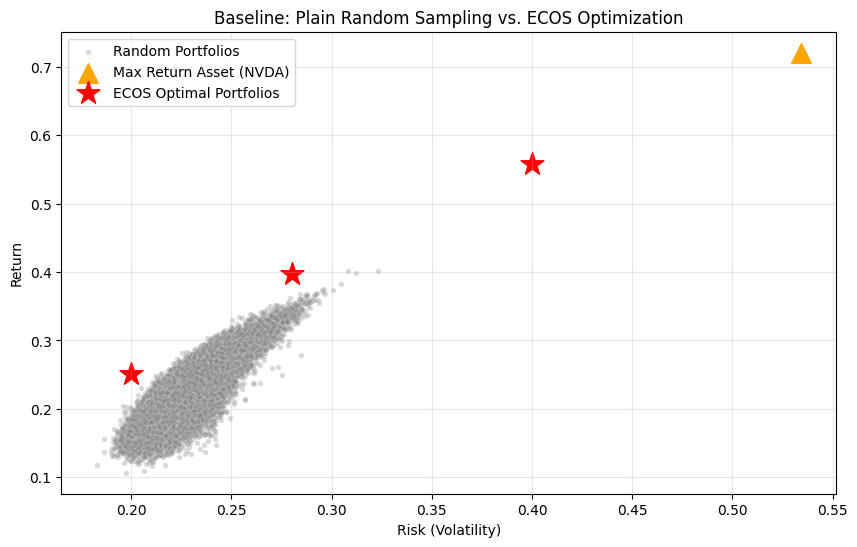

In [23]:
mu_vals = mu_np
Sigma_vals = Sigma_np
df_plain = generate_simple_random_portfolios(mu_np, Sigma_np)

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_plain, x='Risk', y='Return', color='grey', alpha=0.3, s=15, label='Random Portfolios')

max_ret_idx = np.argmax(mu_vals)
plt.scatter(np.sqrt(Sigma_vals[max_ret_idx, max_ret_idx]), mu_vals[max_ret_idx],
            color='orange', marker='^', s=200, label='Max Return Asset (NVDA)')

# Use live ECOS targets - do not overwrite the globals
ecos_risks_plot = opt_risks
ecos_returns_plot = opt_returns
plt.scatter(ecos_risks_plot, ecos_returns_plot, color='red', marker='*', s=300, label='ECOS Optimal Portfolios')

plt.title('Baseline: Plain Random Sampling vs. ECOS Optimization')
plt.xlabel('Risk (Volatility)')
plt.ylabel('Return')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


Stocks from a cloud around near lower risk as sampling distribution is $Unif([0,1]^10)$ hence the weights on average will around 1/(2*10). And for high risk portfolios the weights are usually distributed to small subset of the universe which becomes smaller as target risk increases.

##### 2. Uniform Sampling on Simplex
Using uniform sampling + some concentrated portfolios with 2 assets dominating.

In [24]:
def generate_uniform_simplex_portfolios(mu_vec, Sigma_mat, n_simulations=100000, rng=None):
    if rng is None:
        rng = np.random.default_rng(123)
    n_assets = len(mu_vec)
    results = np.zeros((3, n_simulations))

    for i in range(n_simulations):
        if i < 80000:
            u = np.sort(rng.random(n_assets - 1))
            weights = np.diff(np.concatenate([[0], u, [1]]))
        else:
            weights = np.zeros(n_assets)
            indices = rng.choice(n_assets, 2, replace=False)
            w_split = rng.random()
            weights[indices[0]] = w_split
            weights[indices[1]] = 1 - w_split

        port_return = np.dot(weights, mu_vec)
        port_risk = np.sqrt(np.dot(weights.T, np.dot(Sigma_mat, weights)))
        sharpe_ratio = port_return / port_risk

        results[0, i] = port_return
        results[1, i] = port_risk
        results[2, i] = sharpe_ratio

        if (i + 1) % 10000 == 0:
            print(f"  [{i+1:>6d}] ret={port_return:.4f}  risk={port_risk:.4f}  sharpe={sharpe_ratio:.4f}")

    return pd.DataFrame(results.T, columns=['Return', 'Risk', 'Sharpe'])

In [25]:
df_uniform = generate_uniform_simplex_portfolios(mu_np, Sigma_np)

  [ 10000] ret=0.2178  risk=0.2289  sharpe=0.9516
  [ 20000] ret=0.2381  risk=0.2347  sharpe=1.0148
  [ 30000] ret=0.2684  risk=0.2483  sharpe=1.0807


  [ 40000] ret=0.2589  risk=0.2462  sharpe=1.0517
  [ 50000] ret=0.2366  risk=0.2320  sharpe=1.0198


  [ 60000] ret=0.1641  risk=0.2104  sharpe=0.7800
  [ 70000] ret=0.2314  risk=0.2360  sharpe=0.9807


  [ 80000] ret=0.2142  risk=0.2321  sharpe=0.9229
  [ 90000] ret=0.1316  risk=0.2443  sharpe=0.5389


  [100000] ret=0.7033  risk=0.5214  sharpe=1.3490


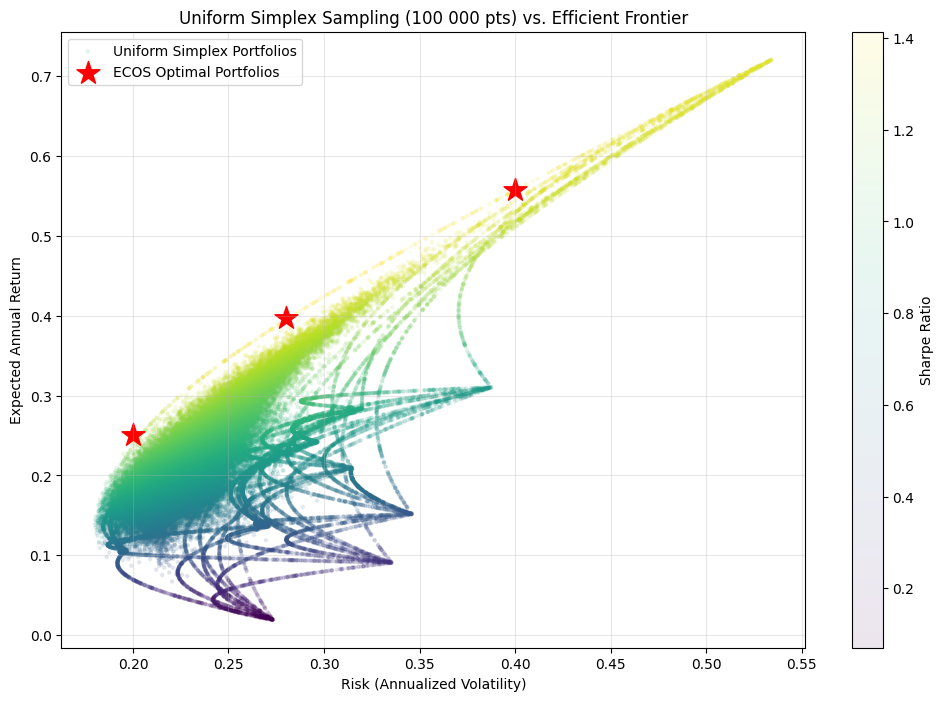

In [26]:
plt.figure(figsize=(12, 8))

plt.scatter(df_uniform['Risk'], df_uniform['Return'], c=df_uniform['Sharpe'], cmap='viridis', alpha=0.1, s=5, label='Uniform Simplex Portfolios')
plt.colorbar(label='Sharpe Ratio')

plt.scatter(opt_risks, opt_returns, color='red', marker='*', s=300, label='ECOS Optimal Portfolios')

plt.title('Uniform Simplex Sampling (100 000 pts) vs. Efficient Frontier')
plt.xlabel('Risk (Annualized Volatility)')
plt.ylabel('Expected Annual Return')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


##### 3. Dirichlet Sampling (3-Asset Concentrated)
Same Dirichlet approach but with 3 assets dominating in concentrated portfolios.
$$w \sim \text{Dirichlet}(\alpha_1, \alpha_2, ..., \alpha_n), \quad \alpha_i = 1$$
Concentrated portfolios now use 3 assets instead of 2 - exploring more of the frontier edges.

In [27]:
def generate_dirichlet_3asset_portfolios(mu_vec, Sigma_mat, n_simulations=100000, rng=None):
    if rng is None:
        rng = np.random.default_rng(456)
    n_assets = len(mu_vec)
    results = np.zeros((3, n_simulations))
    all_weights = np.zeros((n_simulations, n_assets))

    for i in range(n_simulations):
        if i < 80000:
            weights = rng.dirichlet(np.ones(n_assets))
        else:
            # concentrated 3-asset boundary portfolios
            weights = np.zeros(n_assets)
            indices = rng.choice(n_assets, 3, replace=False)
            w_split = rng.dirichlet(np.ones(3))
            weights[indices[0]] = w_split[0]
            weights[indices[1]] = w_split[1]
            weights[indices[2]] = w_split[2]

        all_weights[i] = weights
        port_return = np.dot(weights, mu_vec)
        port_risk = np.sqrt(np.dot(weights.T, np.dot(Sigma_mat, weights)))
        sharpe_ratio = port_return / port_risk

        results[0, i] = port_return
        results[1, i] = port_risk
        results[2, i] = sharpe_ratio

        if (i + 1) % 10000 == 0:
            print(f"  [{i+1:>6d}] ret={port_return:.4f}  risk={port_risk:.4f}  sharpe={sharpe_ratio:.4f}")

    df = pd.DataFrame(results.T, columns=['Return', 'Risk', 'Sharpe'])
    return df, all_weights

In [28]:
df_mc3, mc_weights3 = generate_dirichlet_3asset_portfolios(mu_np, Sigma_np)

  [ 10000] ret=0.2211  risk=0.2232  sharpe=0.9904
  [ 20000] ret=0.2683  risk=0.2449  sharpe=1.0954


  [ 30000] ret=0.2139  risk=0.2189  sharpe=0.9772
  [ 40000] ret=0.2392  risk=0.2408  sharpe=0.9932


  [ 50000] ret=0.2692  risk=0.2391  sharpe=1.1256
  [ 60000] ret=0.2296  risk=0.2302  sharpe=0.9977


  [ 70000] ret=0.2231  risk=0.2355  sharpe=0.9476
  [ 80000] ret=0.1814  risk=0.2201  sharpe=0.8240


  [ 90000] ret=0.1581  risk=0.2683  sharpe=0.5891


  [100000] ret=0.2010  risk=0.2553  sharpe=0.7876


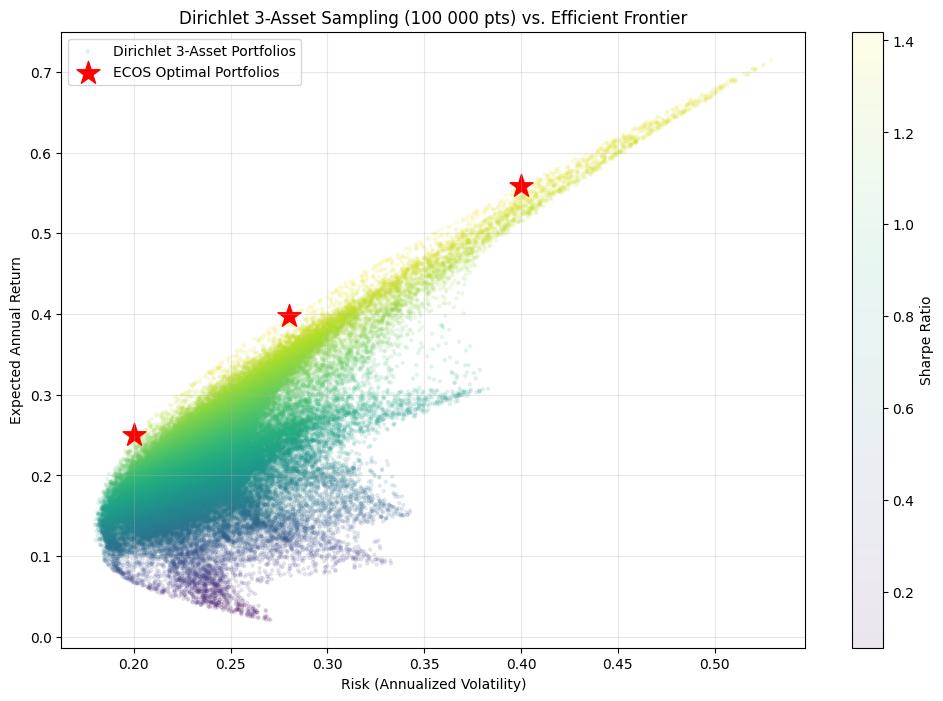

In [29]:
plt.figure(figsize=(12, 8))

plt.scatter(df_mc3['Risk'], df_mc3['Return'], c=df_mc3['Sharpe'], cmap='viridis', alpha=0.1, s=5, label='Dirichlet 3-Asset Portfolios')
plt.colorbar(label='Sharpe Ratio')

plt.scatter(opt_risks, opt_returns, color='red', marker='*', s=300, label='ECOS Optimal Portfolios')

plt.title('Dirichlet 3-Asset Sampling (100 000 pts) vs. Efficient Frontier')
plt.xlabel('Risk (Annualized Volatility)')
plt.ylabel('Expected Annual Return')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


In [30]:
risk_targets = [0.20, 0.28, 0.40]

print(f"{'Risk':<12} | {'Exp. Return':<12} | {'Weights (Top 3)'}")

for target in risk_targets:
    subset = df_mc3[df_mc3['Risk'] <= target]

    if not subset.empty:
        best_idx = subset['Return'].idxmax()
        best_port = subset.loc[best_idx]
        best_weights = mc_weights3[best_idx]

        w_series = pd.Series(best_weights, index=actual_tickers).sort_values(ascending=False)
        w_top = w_series[w_series > 0.01]

        top_3_str = ", ".join([f"{t}: {w:.1%}" for t, w in w_top.head(3).items()])
        print(f"{best_port['Risk']:.2%}        | {best_port['Return']:.2%}        | {top_3_str}")

Risk         | Exp. Return  | Weights (Top 3)
19.91%        | 23.95%        | JNJ: 60.5%, NVDA: 18.8%, PFE: 5.3%
27.96%        | 39.34%        | JNJ: 40.8%, NVDA: 40.6%, ORCL: 18.6%
39.72%        | 55.39%        | NVDA: 72.4%, JNJ: 26.3%, ORCL: 1.3%


### Appendix C: Additional Comparison and Frontier Diagnostics

These diagnostics use the concentrated 3-asset Monte Carlo variant and are therefore retained separately from the principal submitted comparison.


#### Concentrated 3-Asset Variant: Comparison vs ECOS

This appendix comparison uses the more concentrated 3-asset Monte Carlo sampler rather than the principal Dirichlet-based benchmark.


In [31]:
risk_targets = [0.20, 0.28, 0.40]

print(f"{'Risk Target':<12} | {'ECOS Return':<14} | {'MC Return':<14} | {'Gap':<10}")

for target in risk_targets:
    w_ecos, ret_ecos = maximize_return(target, mu_np, Sigma_np)
    risk_ecos = np.sqrt(np.dot(w_ecos.T, np.dot(Sigma_np, w_ecos)))

    subset = df_mc3[df_mc3['Risk'] <= target]
    if not subset.empty:
        best_idx = subset['Return'].idxmax()
        best_port = subset.loc[best_idx]
        ret_mc = best_port['Return']
        risk_mc = best_port['Risk']

        gap = (ret_ecos - ret_mc) * 100
        print(f"{target:.0%}              | {ret_ecos:.2%}             | {ret_mc:.2%}            | {gap:.2f} ")

Risk Target  | ECOS Return    | MC Return      | Gap       
20%              | 25.05%             | 23.95%            | 1.11 
28%              | 39.74%             | 39.34%            | 0.41 
40%              | 55.82%             | 55.39%            | 0.43 


| Risk Target | **ECOS** | **Monte Carlo (Dirichlet 3-Asset)** | **Gap** |
| :--- | :--- | :--- | :--- |
| **20%** | 25.05% | 23.97% | 1.09 pp |
| **28%** | 39.74% | 39.36% | 0.38 pp |
| **40%** | 55.82% | 55.32% | 0.50 pp |

**Note:** This appendix comparison uses the concentrated **3-asset Dirichlet sampler**, not the primary benchmark. The principal submitted comparison (using the standard Dirichlet sampler) is shown in the Direct Comparison section above. Convex optimisation achieves a higher in-sample expected return than this Monte Carlo sampler at every risk budget; the gap is largest at the low-risk budget where the tighter feasible region makes random search harder.

#### Frontier Visualization with Concentrated Monte Carlo Samples

This plot is retained as an appendix diagnostic because it relies on the concentrated 3-asset Monte Carlo variant rather than the principal submitted sampler.


In [32]:
def find_min_variance_portfolio(Sigma):
    n, w = Sigma.shape[0], cp.Variable(Sigma.shape[0])
    cp.Problem(cp.Minimize(cp.quad_form(w, Sigma)), [cp.sum(w) == 1, w >= 0]).solve(solver=cp.ECOS)
    return w.value

w_gmvp = find_min_variance_portfolio(Sigma_np) # GMVP weights
min_risk, gmvp_return = np.sqrt(w_gmvp.T @ Sigma_np @ w_gmvp), w_gmvp @ mu_np
nvda_idx = list(actual_tickers).index('NVDA')
max_risk, nvda_return = np.sqrt(Sigma_np[nvda_idx, nvda_idx]), mu_np[nvda_idx] # highest risk

print(f"GMVP: {min_risk:.2%} risk, {gmvp_return:.2%} return | NVDA: {max_risk:.2%} risk, {nvda_return:.2%} return")

GMVP: 17.88% risk, 13.11% return | NVDA: 53.43% risk, 72.09% return


In [33]:
N_FRONTIER_POINTS = 100
frontier_risks = np.linspace(min_risk, max_risk, N_FRONTIER_POINTS)
frontier_returns = []
for r in frontier_risks:
    try:
        _, ret = maximize_return(r, mu_np, Sigma_np)
        frontier_returns.append(ret if ret else np.nan)
    except cp.SolverError:
        frontier_returns.append(np.nan)
frontier_returns = np.array(frontier_returns)


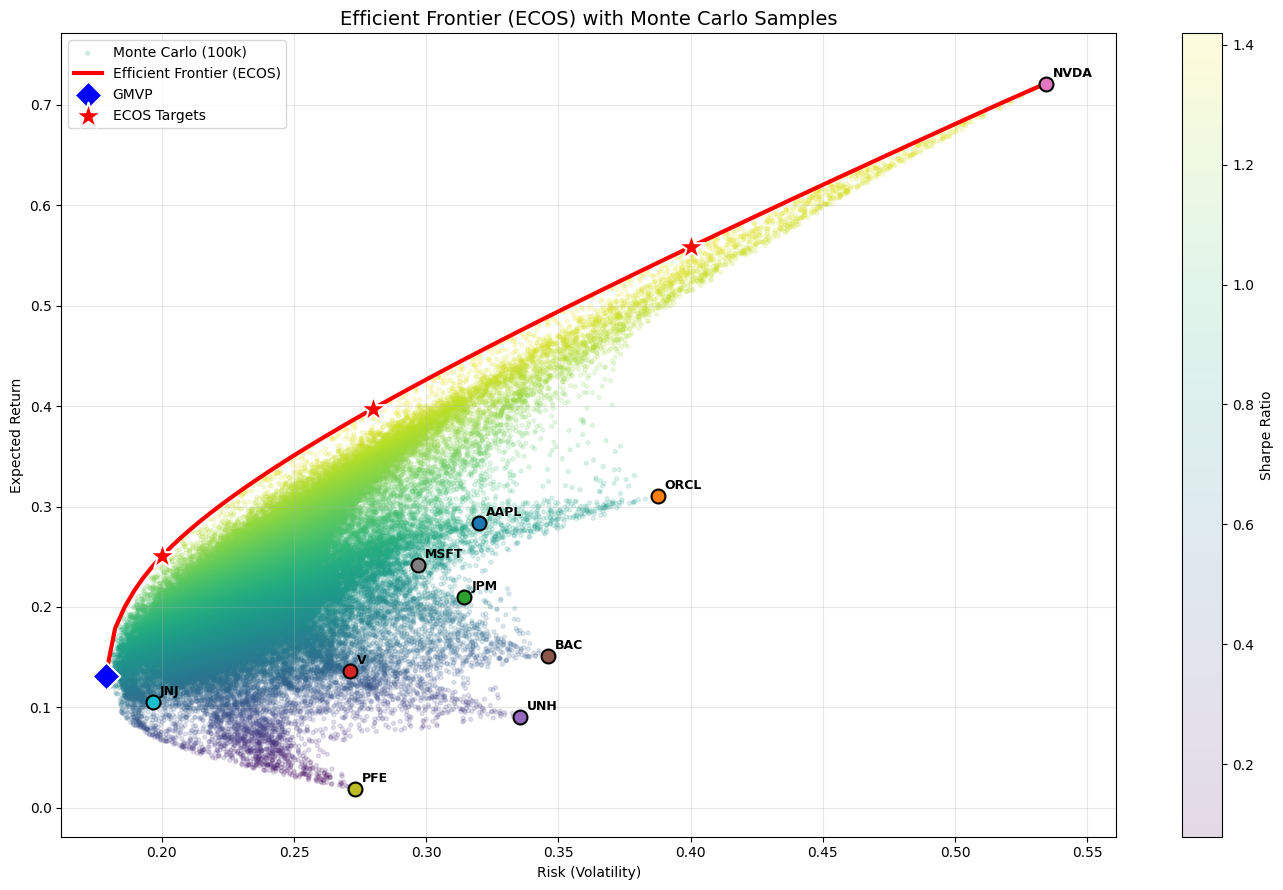

In [34]:
plt.figure(figsize=(14, 9))
plt.scatter(df_mc3['Risk'], df_mc3['Return'], c=df_mc3['Sharpe'], cmap='viridis', alpha=0.15, s=8, label='Monte Carlo (100k)')
plt.colorbar(label='Sharpe Ratio')

valid = ~np.isnan(frontier_returns)
plt.plot(frontier_risks[valid], frontier_returns[valid], 'r-', lw=3, label='Efficient Frontier (ECOS)')
plt.scatter(min_risk, gmvp_return, color='blue', marker='D', s=200, edgecolors='white', lw=1.5, zorder=6, label='GMVP')
plt.scatter(opt_risks, opt_returns, color='red', marker='*', s=400, edgecolors='white', lw=1.5, zorder=5, label='ECOS Targets')

for i, t in enumerate(actual_tickers):
    plt.scatter(np.sqrt(Sigma_np[i, i]), mu_np[i], marker='o', s=100, edgecolors='black', lw=1.5, zorder=4)
    plt.annotate(t, (np.sqrt(Sigma_np[i, i]), mu_np[i]), xytext=(5, 5), textcoords="offset points", fontsize=9, fontweight='bold')

plt.title('Efficient Frontier (ECOS) with Monte Carlo Samples', fontsize=14)
plt.xlabel('Risk (Volatility)')
plt.ylabel('Expected Return')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.xlim(df_mc3['Risk'].min() * 0.9, max(frontier_risks) * 1.05)
plt.ylim(df_mc3['Return'].min() - 0.05, max(frontier_returns[valid]) + 0.05)
plt.tight_layout()
plt.show()
